# Cross-case flow controls on Voronoï particle heterogeneity

This notebook keeps the existing particle heterogeneity diagnostic \(H_\nu\)
and the case-trajectory presentation, but replaces fixed-threshold excess mass
by **quantile-tail means**.

For each selected snapshot:

- strain-tail strength is the mean normalized strain in the strongest 5% of cells;
- cyclonic-tail strength is the mean Rossby number in the upper 5% of cells;
- anticyclonic-tail strength is the mean magnitude of Rossby number in the lower
  5% of cells.

These diagnostics do not require an arbitrary amplitude threshold. Cyclonic and
anticyclonic tails remain separate, so strong activity on both sides cannot cancel.

The figure retains:

- all particle classes in the same panels;
- one thin case trajectory based on the particle-class mean \(H_\nu\);
- arrows indicating the direction of time;
- absolute selected-snapshot values at \(T=0,\ 3,\ 7,\ 13\) days;
- 3D and 2D columns, with divergence shown only for 3D.

In [31]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import json
import importlib
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# Notebook location:
# THESIS/z.parcels_postprocessing/notebooks/
NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
PARCELS_DIR = PROJECT_DIR / "z.parcels_postprocessing"
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

PARCELS_RESULTS_ROOT = (PARCELS_DIR / "results").resolve()
FLOW_RESULTS_ROOT = (FLOW_DIR / "results").resolve()
FLOW_INPUT_DIR = (FLOW_DIR / "data" / "input").resolve()

for path in [PROJECT_DIR, FLOW_SCRIPTS_DIR, PARCELS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()

importlib.reload(shu)
shu.apply_plot_style()


def apply_cross_case_style():
    """Use the same large-format sizing as the existing cross-case notebooks."""
    shu.apply_plot_style()
    plt.rcParams.update({
        "font.size": max(getattr(ptheme, "FONT_SIZE", 14), 17),
        "axes.titlesize": max(getattr(ptheme, "TITLE_SIZE", 20), 22),
        "axes.labelsize": max(getattr(ptheme, "LABEL_SIZE", 18), 19),
        "xtick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 16),
        "ytick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 16),
        "legend.fontsize": max(getattr(ptheme, "LEGEND_SIZE", 15), 15),
        "figure.titlesize": max(getattr(ptheme, "SUPTITLE_SIZE", 24), 25),
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.transparent": False,
    })


apply_cross_case_style()

print(f"Notebook dir       : {NB_DIR}")
print(f"Particle results   : {PARCELS_RESULTS_ROOT}")
print(f"Flow input         : {FLOW_INPUT_DIR}")
print(f"Flow results       : {FLOW_RESULTS_ROOT}")
print(f"Utilities          : {Path(shu.__file__).resolve()}")

Notebook dir       : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\notebooks
Particle results   : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results
Flow input         : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input
Flow results       : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results
Utilities          : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\scripts\shcherbina_utils.py


In [32]:
# ============================================================
# 2. USER SETTINGS
# ============================================================

CASE_NAMES = [
    "run_aug1", "run_aug1_f1", "run_aug1_f2", "run_aug2", "run_aug3",
    "run_dec1", "run_dec2", "run_feb1", "run_jan1", "run_jul1",
    "run_jun1", "run_mar1", "run_may1", "run_nov1", "run_oct1", "run_sep1",
]

PARTICLE_TYPES_TO_PLOT = [
    "Passive particles",
    "GDP drifter",
    "Simple megaplastic",
]

HETEROGENEITY_CACHE_FILENAME = (
    "particle_heterogeneity_2D_vs_3D_selected_snapshots.nc"
)
ACTIVITY_CACHE_FILENAME = "submesoscale_activity_selected_snapshots.nc"

# New cache name prevents reuse of earlier fixed-threshold diagnostics.
FLOW_CONTROL_CACHE_FILENAME = (
    "particle_flow_controls_tail_means_selected_snapshots.nc"
)

REBUILD_FLOW_CONTROL_CACHES = False
USE_EXISTING_ACTIVITY_CACHE = True
USE_EXISTING_DIVERGENCE_JSON = True
SKIP_MISSING_CASES = True

LEVEL_INDICES_3D = (0,)
LEVEL_INDICES_2D = (0,)
DX_3D_FALLBACK = None
DY_3D_FALLBACK = None
DX_2D_FALLBACK = None
DY_2D_FALLBACK = None

ACTIVE_RO_THRESHOLD = 0.5

# Quantile-tail definitions.
UPPER_TAIL_PERCENTILE = 95.0
LOWER_TAIL_PERCENTILE = 5.0

# Absolute selected snapshots used in the trajectory figure.
PLOT_DAYS = (0.0, 3.0, 7.0, 13.0)
SNAPSHOT_MARKERS = {
    0.0: "o",
    3.0: "s",
    7.0: "^",
    13.0: "D",
}

DEFAULT_F0 = 8.0e-5
F0_BY_CASE = {
    "run_aug1_f1": 1.0e-4,
    "run_aug1_f1_2D": 1.0e-4,
    "run_aug1_f2": 6.0e-5,
    "run_aug1_f2_2D": 6.0e-5,
}

# Particle points.
POINT_SIZE = 34
POINT_ALPHA = 0.88
POINT_EDGE_WIDTH = 0.6

# Case-mean trajectory overlays.
CASE_LINE_COLOR = "0.58"
CASE_LINE_WIDTH = 0.85
CASE_LINE_ALPHA = 0.85
CASE_ARROW_SCALE = 9

SAVE_FIGURES = True
SAVE_PNG = True
SAVE_PDF = True
SAVE_SUMMARY_CSV = True

OUTPUT_DIR = (
    PARCELS_RESULTS_ROOT
    / "_comparisons"
    / "cross_case_particle_flow_controls_tail_means"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV_PATH = (
    OUTPUT_DIR / "particle_heterogeneity_flow_controls_tail_means.csv"
)

PARTICLE_COLORS = {
    "Passive particles": shu.get_color("default"),
    "GDP drifter": shu.get_color("secondary"),
    "Simple megaplastic": shu.get_color("highlight"),
}

print(f"Output directory        : {OUTPUT_DIR}")
print(f"Active-Ro threshold     : {ACTIVE_RO_THRESHOLD:g}")
print(f"Upper tail percentile   : {UPPER_TAIL_PERCENTILE:g}")
print(f"Lower tail percentile   : {LOWER_TAIL_PERCENTILE:g}")
print(f"Plotted snapshots [days]: {PLOT_DAYS}")

Output directory        : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_tail_means
Active-Ro threshold     : 0.5
Upper tail percentile   : 95
Lower tail percentile   : 5
Plotted snapshots [days]: (0.0, 3.0, 7.0, 13.0)


In [33]:
# ============================================================
# 3. GENERAL HELPERS
# ============================================================

def text(value):
    return value.decode("utf-8") if isinstance(value, bytes) else str(value)


def slug(value):
    return re.sub(r"[^A-Za-z0-9_-]+", "_", str(value)).strip("_").lower()


def particle_type(label):
    label = " ".join(text(label).lower().split())
    if "passive" in label:
        return "Passive particles"
    if "gdp" in label and "drifter" in label:
        return "GDP drifter"
    if "megaplastic" in label:
        return "Simple megaplastic"
    return None


def dataset_layout(ds):
    time_dim = shu.find_dim(ds["UVEL"].dims, ["T", "time", "iter"])
    z_dim = shu.find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])
    return time_dim, z_dim


def infer_grid_spacing(ds, coordinate_name, fallback=None):
    if coordinate_name in ds.coords:
        coordinate = np.asarray(ds[coordinate_name].values, dtype=float)
        if coordinate.size > 1:
            spacing = float(np.nanmedian(np.abs(np.diff(coordinate))))
            if np.isfinite(spacing) and spacing > 0.0:
                return spacing

    if fallback is not None:
        return float(fallback)

    raise ValueError(
        f"Could not infer grid spacing from coordinate {coordinate_name!r}."
    )


def resolve_f0(case_name, ds=None):
    """Resolve the Coriolis frequency for one case."""
    if case_name in F0_BY_CASE:
        return float(F0_BY_CASE[case_name])

    if ds is not None:
        for key in ("f0_s-1", "f0", "fCori", "coriolis_parameter"):
            if key in ds.attrs:
                value = float(np.asarray(ds.attrs[key]).squeeze())
                if np.isfinite(value) and value != 0.0:
                    return value

    return float(DEFAULT_F0)



def finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]


def upper_tail_statistics(values, percentile=UPPER_TAIL_PERCENTILE):
    """
    Return the percentile boundary and mean value within the upper tail.
    """
    values = finite_values(values)
    if values.size == 0:
        return {
            "quantile": np.nan,
            "tail_mean": np.nan,
            "tail_count": 0,
            "tail_fraction": np.nan,
        }

    quantile = float(np.nanpercentile(values, percentile))
    tail = values[values >= quantile]

    return {
        "quantile": quantile,
        "tail_mean": float(np.nanmean(tail)),
        "tail_count": int(tail.size),
        "tail_fraction": float(tail.size / values.size),
    }


def lower_tail_magnitude_statistics(
    values,
    percentile=LOWER_TAIL_PERCENTILE,
):
    """
    Return the lower percentile boundary and mean positive magnitude
    within the lower tail.
    """
    values = finite_values(values)
    if values.size == 0:
        return {
            "quantile": np.nan,
            "tail_mean_magnitude": np.nan,
            "tail_count": 0,
            "tail_fraction": np.nan,
        }

    quantile = float(np.nanpercentile(values, percentile))
    tail = values[values <= quantile]

    return {
        "quantile": quantile,
        "tail_mean_magnitude": float(np.nanmean(-tail)),
        "tail_count": int(tail.size),
        "tail_fraction": float(tail.size / values.size),
    }


def full_domain_active_fraction(ro, threshold=ACTIVE_RO_THRESHOLD):
    """Reuse the helper already used in compare_2D_3D_flow.ipynb."""
    ro = np.asarray(ro, dtype=float)
    ny, nx = ro.shape[-2:]
    full_domain = [{
        "square_id": 1,
        "x0": 0,
        "x1": nx,
        "y0": 0,
        "y1": ny,
    }]
    result = shu.compute_pro_per_square(ro, full_domain, threshold)
    return float(result[0]["PRo"])


def divergence_rms_normalized(div_f):
    div_f = np.asarray(div_f, dtype=float)
    finite = np.isfinite(div_f)
    if not np.any(finite):
        return np.nan
    return float(np.sqrt(np.nanmean(div_f[finite] ** 2)))



def flow_structure_metrics(ro, strain_f, div_f, f0):
    """
    Summarize one selected flow snapshot using quantile-tail means.
    """
    ro = np.asarray(ro, dtype=float)
    strain_f = np.asarray(strain_f, dtype=float)
    div_f = np.asarray(div_f, dtype=float)

    strain_tail = upper_tail_statistics(
        strain_f,
        percentile=UPPER_TAIL_PERCENTILE,
    )
    cyclonic_tail = upper_tail_statistics(
        ro,
        percentile=UPPER_TAIL_PERCENTILE,
    )
    anticyclonic_tail = lower_tail_magnitude_statistics(
        ro,
        percentile=LOWER_TAIL_PERCENTILE,
    )

    div_rms_norm = divergence_rms_normalized(div_f)

    return {
        "active_fraction": full_domain_active_fraction(
            ro,
            threshold=ACTIVE_RO_THRESHOLD,
        ),
        "strain_q95": strain_tail["quantile"],
        "strain_tail_mean_95": strain_tail["tail_mean"],
        "strain_tail_fraction_95": strain_tail["tail_fraction"],
        "ro_q95": cyclonic_tail["quantile"],
        "ro_cyclonic_tail_mean_95": cyclonic_tail["tail_mean"],
        "ro_cyclonic_tail_fraction_95": cyclonic_tail["tail_fraction"],
        "ro_q05": anticyclonic_tail["quantile"],
        "ro_anticyclonic_tail_mean_05": (
            anticyclonic_tail["tail_mean_magnitude"]
        ),
        "ro_anticyclonic_tail_fraction_05": (
            anticyclonic_tail["tail_fraction"]
        ),
        "divergence_rms_normalized": div_rms_norm,
        "divergence_rms_s1": abs(float(f0)) * div_rms_norm,
    }


def load_characterization(case_name):
    path = (
        FLOW_RESULTS_ROOT
        / case_name
        / f"{case_name}_domain_characterization.json"
    )
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def existing_divergence_by_obs(case_name):
    """Reuse saved selected-snapshot dimensional divergence RMS."""
    characterization = load_characterization(case_name)
    values = characterization.get(
        "divergence_rms_selected_snapshots_s-1",
        {},
    )
    return {
        int(key): float(value)
        for key, value in values.items()
    }


def load_existing_activity_by_obs(case_name, simulation_label):
    """Return cached active fractions keyed by observation index."""
    path = (
        FLOW_RESULTS_ROOT
        / case_name
        / "metrics"
        / ACTIVITY_CACHE_FILENAME
    )
    if not path.exists() or not USE_EXISTING_ACTIVITY_CACHE:
        return {}

    with xr.open_dataset(path) as ds_open:
        ds = ds_open.load()

    cached_threshold = float(
        ds.attrs.get("active_ro_threshold", ACTIVE_RO_THRESHOLD)
    )
    if not np.isclose(cached_threshold, ACTIVE_RO_THRESHOLD):
        warnings.warn(
            f"Ignoring {path.name} for {case_name}: threshold "
            f"{cached_threshold:g} differs from {ACTIVE_RO_THRESHOLD:g}."
        )
        return {}

    value_name = (
        "active_fraction_3d"
        if simulation_label == "3D"
        else "active_fraction_2d"
    )
    if "obs_index" not in ds or value_name not in ds:
        return {}

    return {
        int(obs): float(value)
        for obs, value in zip(
            ds["obs_index"].values,
            ds[value_name].values,
        )
    }


def padded_limits(values, fractional_pad=0.07, include_zero=False):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None

    lo = float(np.nanmin(values))
    hi = float(np.nanmax(values))

    if include_zero:
        lo = min(lo, 0.0)
        hi = max(hi, 0.0)

    if np.isclose(lo, hi):
        scale = max(abs(lo), 1.0)
        return lo - 0.05 * scale, hi + 0.05 * scale

    pad = fractional_pad * (hi - lo)
    return lo - pad, hi + pad


def select_plot_days(data):
    mask = np.zeros(len(data), dtype=bool)
    for day in PLOT_DAYS:
        mask |= np.isclose(data["time_days"].to_numpy(dtype=float), day)
    return data.loc[mask].copy()


def snapshot_legend_handles():
    return [
        Line2D(
            [0],
            [0],
            marker=SNAPSHOT_MARKERS[day],
            linestyle="none",
            markerfacecolor="0.55",
            markeredgecolor="white",
            markeredgewidth=0.8,
            markersize=8,
            label=f"T={day:g} d",
        )
        for day in PLOT_DAYS
    ]


def particle_legend_handles():
    return [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=PARTICLE_COLORS[group],
            markeredgecolor="white",
            markeredgewidth=0.8,
            markersize=8,
            label=group,
        )
        for group in PARTICLE_TYPES_TO_PLOT
    ]


def save_figure(fig, filename_base):
    if not SAVE_FIGURES:
        return

    if SAVE_PNG:
        path = OUTPUT_DIR / f"{filename_base}.png"
        fig.savefig(
            path,
            dpi=getattr(ptheme, "SAVE_DPI", 300),
            bbox_inches="tight",
            facecolor="white",
            transparent=False,
        )
        print(f"Saved: {path}")

    if SAVE_PDF:
        path = OUTPUT_DIR / f"{filename_base}.pdf"
        fig.savefig(
            path,
            bbox_inches="tight",
            facecolor="white",
            transparent=False,
        )
        print(f"Saved: {path}")

In [34]:
# ============================================================
# 4. LOAD THE EXISTING HETEROGENEITY CACHES
# ============================================================

def heterogeneity_cache_path(case_name):
    return (
        FLOW_RESULTS_ROOT
        / case_name
        / "metrics"
        / HETEROGENEITY_CACHE_FILENAME
    )


def load_heterogeneity_case(case_name):
    path = heterogeneity_cache_path(case_name)
    if not path.exists():
        raise FileNotFoundError(path)

    with xr.open_dataset(path) as ds_open:
        ds = ds_open.load()

    return ds


heterogeneity_datasets = {}
skipped_heterogeneity = []

for case_name in CASE_NAMES:
    try:
        ds = load_heterogeneity_case(case_name)
        heterogeneity_datasets[case_name] = ds
        print(
            f"Loaded heterogeneity: {case_name} "
            f"({ds.sizes['particle_class']} classes, "
            f"{ds.sizes['snapshot']} snapshots)"
        )
    except Exception as exc:
        message = f"{case_name}: {type(exc).__name__}: {exc}"
        if not SKIP_MISSING_CASES:
            raise
        skipped_heterogeneity.append(message)
        warnings.warn(message)

if not heterogeneity_datasets:
    raise RuntimeError("No selected-snapshot heterogeneity caches were loaded.")

Loaded heterogeneity: run_aug1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_aug1_f1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_aug1_f2 (3 classes, 4 snapshots)
Loaded heterogeneity: run_aug2 (3 classes, 4 snapshots)
Loaded heterogeneity: run_aug3 (3 classes, 4 snapshots)
Loaded heterogeneity: run_dec1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_dec2 (3 classes, 4 snapshots)
Loaded heterogeneity: run_feb1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_jan1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_jul1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_jun1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_mar1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_may1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_nov1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_oct1 (3 classes, 4 snapshots)
Loaded heterogeneity: run_sep1 (3 classes, 4 snapshots)


## Selected-snapshot flow-control cache

Each case receives a compact cache in

`z.flow_postprocessing/results/<case>/metrics/particle_flow_controls_tail_mass_selected_snapshots.nc`.

Existing heterogeneity, submesoscale-activity and divergence outputs are reused.
Missing strong-structure diagnostics are calculated from selected flow snapshots
with `shcherbina_utils.compute_surface_kinematics`.

In [35]:
# ============================================================
# 5. BUILD OR LOAD SELECTED-SNAPSHOT FLOW-CONTROL CACHES
# ============================================================

def flow_input_path(case_name):
    return FLOW_INPUT_DIR / f"{case_name}.nc"


def flow_control_cache_path(case_3d):
    return (
        FLOW_RESULTS_ROOT
        / case_3d
        / "metrics"
        / FLOW_CONTROL_CACHE_FILENAME
    )



def cache_matches_selection(ds, obs_3d, obs_2d):
    try:
        same_obs_3d = np.array_equal(
            np.asarray(ds["obs_index_3d"].values, dtype=int),
            np.asarray(obs_3d, dtype=int),
        )
        same_obs_2d = np.array_equal(
            np.asarray(ds["obs_index_2d"].values, dtype=int),
            np.asarray(obs_2d, dtype=int),
        )
        same_active_threshold = np.isclose(
            float(ds.attrs["active_ro_threshold"]),
            float(ACTIVE_RO_THRESHOLD),
        )
        same_upper_percentile = np.isclose(
            float(ds.attrs["upper_tail_percentile"]),
            float(UPPER_TAIL_PERCENTILE),
        )
        same_lower_percentile = np.isclose(
            float(ds.attrs["lower_tail_percentile"]),
            float(LOWER_TAIL_PERCENTILE),
        )
    except Exception:
        return False

    return bool(
        same_obs_3d
        and same_obs_2d
        and same_active_threshold
        and same_upper_percentile
        and same_lower_percentile
    )


def compute_simulation_controls(
    case_name,
    obs_indices,
    level_indices,
    dx_fallback,
    dy_fallback,
    simulation_label,
    paired_case_3d,
):
    path = flow_input_path(case_name)
    if not path.exists():
        raise FileNotFoundError(path)

    cached_activity = load_existing_activity_by_obs(
        paired_case_3d,
        simulation_label,
    )
    cached_divergence = (
        existing_divergence_by_obs(paired_case_3d)
        if simulation_label == "3D" and USE_EXISTING_DIVERGENCE_JSON
        else {}
    )

    records = []

    with xr.open_dataset(
        path,
        decode_times=False,
        cache=False,
    ) as ds:
        time_dim, z_dim = dataset_layout(ds)
        dx = infer_grid_spacing(ds, "X", fallback=dx_fallback)
        dy = infer_grid_spacing(ds, "Y", fallback=dy_fallback)
        f0 = resolve_f0(case_name, ds=ds)
        n_time = int(ds.sizes[time_dim])

        for obs_index in np.asarray(obs_indices, dtype=int):
            if obs_index < 0 or obs_index >= n_time:
                raise IndexError(
                    f"{case_name}: selected observation {obs_index} lies "
                    f"outside 0..{n_time - 1}."
                )

            ro, div_f, strain_f = shu.compute_surface_kinematics(
                ds,
                time_dim=time_dim,
                z_dim=z_dim,
                it=int(obs_index),
                levels=list(level_indices),
                dx=float(dx),
                dy=float(dy),
                f0=float(f0),
            )

            metrics = flow_structure_metrics(
                ro=np.asarray(ro, dtype=float),
                strain_f=np.asarray(strain_f, dtype=float),
                div_f=np.asarray(div_f, dtype=float),
                f0=f0,
            )

            if int(obs_index) in cached_activity:
                metrics["active_fraction"] = cached_activity[int(obs_index)]

            if int(obs_index) in cached_divergence:
                metrics["divergence_rms_s1"] = cached_divergence[int(obs_index)]
                metrics["divergence_rms_normalized"] = (
                    cached_divergence[int(obs_index)] / abs(float(f0))
                )

            metrics.update({
                "obs_index": int(obs_index),
                "f0_s1": float(f0),
                "dx_m": float(dx),
                "dy_m": float(dy),
            })
            records.append(metrics)

    return pd.DataFrame(records)


def build_case_flow_control_cache(case_3d, heterogeneity_ds):
    case_2d = text(
        heterogeneity_ds.attrs.get("case_2d", f"{case_3d}_2D")
    )

    obs_3d = np.asarray(
        heterogeneity_ds["requested_obs_index_3d"].values,
        dtype=int,
    )
    obs_2d = np.asarray(
        heterogeneity_ds["requested_obs_index_2d"].values,
        dtype=int,
    )
    time_3d = np.asarray(
        heterogeneity_ds["target_time_days_3d"].values,
        dtype=float,
    )
    time_2d = np.asarray(
        heterogeneity_ds["target_time_days_2d"].values,
        dtype=float,
    )

    cache_path = flow_control_cache_path(case_3d)
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists() and not REBUILD_FLOW_CONTROL_CACHES:
        with xr.open_dataset(cache_path) as ds_open:
            cached = ds_open.load()
        if cache_matches_selection(cached, obs_3d, obs_2d):
            print(f"Loaded flow-control cache: {cache_path}")
            return cached
        warnings.warn(
            f"Rebuilding incompatible flow-control cache: {cache_path}"
        )

    controls_3d = compute_simulation_controls(
        case_name=case_3d,
        obs_indices=obs_3d,
        level_indices=LEVEL_INDICES_3D,
        dx_fallback=DX_3D_FALLBACK,
        dy_fallback=DY_3D_FALLBACK,
        simulation_label="3D",
        paired_case_3d=case_3d,
    )
    controls_2d = compute_simulation_controls(
        case_name=case_2d,
        obs_indices=obs_2d,
        level_indices=LEVEL_INDICES_2D,
        dx_fallback=DX_2D_FALLBACK,
        dy_fallback=DY_2D_FALLBACK,
        simulation_label="2D",
        paired_case_3d=case_3d,
    )

    def values(frame, name):
        return frame[name].to_numpy(dtype=float)

    paired_variables = [
            "active_fraction",
            "strain_q95",
            "strain_tail_mean_95",
            "strain_tail_fraction_95",
            "ro_q95",
            "ro_cyclonic_tail_mean_95",
            "ro_cyclonic_tail_fraction_95",
            "ro_q05",
            "ro_anticyclonic_tail_mean_05",
            "ro_anticyclonic_tail_fraction_05",
        ]

    data_vars = {}
    for variable in paired_variables:
        data_vars[f"{variable}_3d"] = (
            "snapshot",
            values(controls_3d, variable),
        )
        data_vars[f"{variable}_2d"] = (
            "snapshot",
            values(controls_2d, variable),
        )

    data_vars.update({
        "divergence_rms_normalized_3d": (
            "snapshot",
            values(controls_3d, "divergence_rms_normalized"),
        ),
        "divergence_rms_s1_3d": (
            "snapshot",
            values(controls_3d, "divergence_rms_s1"),
        ),
        "f0_3d_s1": (
            "snapshot",
            values(controls_3d, "f0_s1"),
        ),
        "f0_2d_s1": (
            "snapshot",
            values(controls_2d, "f0_s1"),
        ),
    })

    ds = xr.Dataset(
        data_vars=data_vars,
        coords={
            "snapshot": np.arange(obs_3d.size, dtype=int),
            "obs_index_3d": ("snapshot", obs_3d),
            "obs_index_2d": ("snapshot", obs_2d),
            "time_days_3d": ("snapshot", time_3d),
            "time_days_2d": ("snapshot", time_2d),
        },
        attrs={
            "case_3d": case_3d,
            "case_2d": case_2d,
            "active_ro_threshold": float(ACTIVE_RO_THRESHOLD),
            "strain_excess_threshold": float(STRAIN_EXCESS_THRESHOLD),
            "vorticity_excess_threshold": float(
                VORTICITY_EXCESS_THRESHOLD
            ),
            "strain_dominated_only": int(STRAIN_DOMINATED_ONLY),
            "excess_mass_definition": (
                "domain mean of max(field-threshold,0); cells outside "
                "the optional support mask contribute zero"
            ),
            "strain_definition": (
                "mean(max(strain/abs(f0)-strain_threshold,0)) "
                "restricted to strain/abs(f0)>abs(zeta/f0) when enabled"
            ),
            "cyclonic_definition": (
                "mean(max(zeta/f0-vorticity_threshold,0))"
            ),
            "anticyclonic_definition": (
                "mean(max(-zeta/f0-vorticity_threshold,0))"
            ),
            "divergence_definition": (
                "abs(f0)*sqrt(mean((divergence/f0)^2))"
            ),
            "kinematics_function": (
                "shcherbina_utils.compute_surface_kinematics"
            ),
            "description": (
                "Selected-snapshot fixed-threshold flow controls for "
                "cross-case particle-heterogeneity figures."
            ),
        },
    )

    ds.to_netcdf(cache_path)
    print(f"Saved flow-control cache: {cache_path}")
    return ds


flow_control_datasets = {}
skipped_flow = []

for case_name, heterogeneity_ds in heterogeneity_datasets.items():
    try:
        flow_control_datasets[case_name] = build_case_flow_control_cache(
            case_name,
            heterogeneity_ds,
        )
    except Exception as exc:
        message = f"{case_name}: {type(exc).__name__}: {exc}"
        if not SKIP_MISSING_CASES:
            raise
        skipped_flow.append(message)
        warnings.warn(message)

if not flow_control_datasets:
    raise RuntimeError("No flow-control datasets were loaded or built.")

C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_18748\3860243737.py:298: UserWarning: run_aug1: FileNotFoundError: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1_2D.nc
  warnings.warn(message)
C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_18748\3860243737.py:165: UserWarning: Rebuilding incompatible flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f1\metrics\particle_flow_controls_tail_means_selected_snapshots.nc
  warnings.warn(


Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f1\metrics\particle_flow_controls_tail_means_selected_snapshots.nc


C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_18748\3860243737.py:165: UserWarning: Rebuilding incompatible flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f2\metrics\particle_flow_controls_tail_means_selected_snapshots.nc
  warnings.warn(


Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f2\metrics\particle_flow_controls_tail_means_selected_snapshots.nc


C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_18748\3860243737.py:165: UserWarning: Rebuilding incompatible flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug2\metrics\particle_flow_controls_tail_means_selected_snapshots.nc
  warnings.warn(


...

Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_nov1\metrics\particle_flow_controls_tail_means_selected_snapshots.nc


C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_18748\3860243737.py:165: UserWarning: Rebuilding incompatible flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_oct1\metrics\particle_flow_controls_tail_means_selected_snapshots.nc
  warnings.warn(


Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_oct1\metrics\particle_flow_controls_tail_means_selected_snapshots.nc


C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_18748\3860243737.py:165: UserWarning: Rebuilding incompatible flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_sep1\metrics\particle_flow_controls_tail_means_selected_snapshots.nc
  warnings.warn(


Saved flow-control cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_sep1\metrics\particle_flow_controls_tail_means_selected_snapshots.nc


In [36]:
# ============================================================
# 6. ASSEMBLE THE CROSS-CASE TABLE
# ============================================================

def case_rows(case_name, heterogeneity_ds, flow_ds):
    rows = []

    if heterogeneity_ds.sizes["snapshot"] != flow_ds.sizes["snapshot"]:
        raise ValueError(
            f"{case_name}: heterogeneity and flow caches have different "
            "snapshot counts."
        )

    for particle_index in range(
        heterogeneity_ds.sizes["particle_class"]
    ):
        labels = [
            text(heterogeneity_ds[name].values[particle_index])
            for name in (
                "particle_panel_label",
                "source_particle_label_3d",
                "source_particle_label_2d",
                "particle_key",
            )
            if name in heterogeneity_ds
        ]
        label = next(
            (value for value in labels if value),
            f"particle_{particle_index}",
        )
        group = particle_type(label)
        if group is None:
            continue

        for snapshot_index in range(
            heterogeneity_ds.sizes["snapshot"]
        ):
            row = {
                "case_3d": case_name,
                "case_2d": text(
                    heterogeneity_ds.attrs.get(
                        "case_2d",
                        f"{case_name}_2D",
                    )
                ),
                "particle_type": group,
                "particle_label": label,
                "snapshot": snapshot_index,
                "time_days": float(
                    heterogeneity_ds[
                        "target_time_days_3d"
                    ].values[snapshot_index]
                ),
                "obs_index_3d": int(
                    heterogeneity_ds[
                        "requested_obs_index_3d"
                    ].values[snapshot_index]
                ),
                "obs_index_2d": int(
                    heterogeneity_ds[
                        "requested_obs_index_2d"
                    ].values[snapshot_index]
                ),
                "heterogeneity_3d": float(
                    heterogeneity_ds[
                        "heterogeneity_3d"
                    ].values[particle_index, snapshot_index]
                ),
                "heterogeneity_2d": float(
                    heterogeneity_ds[
                        "heterogeneity_2d"
                    ].values[particle_index, snapshot_index]
                ),
            }

            paired_variables = [
                        "active_fraction",
                        "strain_q95",
                        "strain_tail_mean_95",
                        "strain_tail_fraction_95",
                        "ro_q95",
                        "ro_cyclonic_tail_mean_95",
                        "ro_cyclonic_tail_fraction_95",
                        "ro_q05",
                        "ro_anticyclonic_tail_mean_05",
                        "ro_anticyclonic_tail_fraction_05",
                    ]

            for variable in paired_variables:
                for suffix in ("3d", "2d"):
                    name = f"{variable}_{suffix}"
                    row[name] = float(
                        flow_ds[name].values[snapshot_index]
                    )

            for name in (
                "divergence_rms_normalized_3d",
                "divergence_rms_s1_3d",
                "f0_3d_s1",
                "f0_2d_s1",
            ):
                row[name] = float(
                    flow_ds[name].values[snapshot_index]
                )

            row.update({
                        "heterogeneity_bias_2d_minus_3d": (
                            row["heterogeneity_2d"]
                            - row["heterogeneity_3d"]
                        ),
                        "active_fraction_bias_2d_minus_3d": (
                            row["active_fraction_2d"]
                            - row["active_fraction_3d"]
                        ),
                        "strain_tail_mean_95_bias_2d_minus_3d": (
                            row["strain_tail_mean_95_2d"]
                            - row["strain_tail_mean_95_3d"]
                        ),
                        "ro_cyclonic_tail_mean_95_bias_2d_minus_3d": (
                            row["ro_cyclonic_tail_mean_95_2d"]
                            - row["ro_cyclonic_tail_mean_95_3d"]
                        ),
                        "ro_anticyclonic_tail_mean_05_bias_2d_minus_3d": (
                            row["ro_anticyclonic_tail_mean_05_2d"]
                            - row["ro_anticyclonic_tail_mean_05_3d"]
                        ),
                    })
            rows.append(row)

    return rows


records = []
for case_name, flow_ds in flow_control_datasets.items():
    if case_name not in heterogeneity_datasets:
        continue
    records.extend(
        case_rows(
            case_name,
            heterogeneity_datasets[case_name],
            flow_ds,
        )
    )

comparison_df = pd.DataFrame(records)
if comparison_df.empty:
    raise RuntimeError("The combined cross-case table is empty.")

comparison_df["time_days"] = comparison_df["time_days"].round(8)
comparison_df = comparison_df.sort_values(
    ["particle_type", "case_3d", "time_days"]
).reset_index(drop=True)

plot_df = select_plot_days(comparison_df)
if plot_df.empty:
    raise RuntimeError(
        f"No records matched the requested plot days: {PLOT_DAYS}"
    )

display(plot_df)

if SAVE_SUMMARY_CSV:
    comparison_df.to_csv(SUMMARY_CSV_PATH, index=False)
    print(f"Saved: {SUMMARY_CSV_PATH}")

,case_3d,case_2d,particle_type,particle_label,snapshot,time_days,obs_index_3d,obs_index_2d,heterogeneity_3d,heterogeneity_2d,...,ro_anticyclonic_tail_fraction_05_2d,divergence_rms_normalized_3d,divergence_rms_s1_3d,f0_3d_s1,f0_2d_s1,heterogeneity_bias_2d_minus_3d,active_fraction_bias_2d_minus_3d,strain_tail_mean_95_bias_2d_minus_3d,ro_cyclonic_tail_mean_95_bias_2d_minus_3d,ro_anticyclonic_tail_mean_05_bias_2d_minus_3d
0,run_aug1_f1,run_aug1_f1_2D,GDP drifter,"Simple GDP drifter, St=6.438e-03",0,0.0,0,0,1.031283,1.031229,...,0.050003,0.035063,0.000004,0.00010,0.00010,-0.000054,0.001263,0.021169,0.010889,0.005410
1,run_aug1_f1,run_aug1_f1_2D,GDP drifter,"Simple GDP drifter, St=6.438e-03",1,3.0,24,24,1.125255,1.018926,...,0.050003,0.039150,0.000004,0.00010,0.00010,-0.106329,-0.004784,-0.077404,-0.058602,0.005920
2,run_aug1_f1,run_aug1_f1_2D,GDP drifter,"Simple GDP drifter, St=6.438e-03",2,7.0,56,56,1.395064,1.051572,...,0.050003,0.036365,0.000004,0.00010,0.00010,-0.343491,-0.010273,-0.130664,-0.120568,-0.010757
3,run_aug1_f1,run_aug1_f1_2D,GDP drifter,"Simple GDP drifter, St=6.438e-03",3,13.0,104,104,1.763832,1.057308,...,0.050003,0.037564,0.000004,0.00010,0.00010,-0.706523,-0.008064,-0.128600,-0.120262,-0.028505
4,run_aug1_f2,run_aug1_f2_2D,GDP drifter,"Simple GDP drifter, St=4.070e-03",0,0.0,0,0,1.031350,1.031325,...,0.050003,0.067857,0.000004,0.00006,0.00006,-0.000025,-0.000027,0.006512,0.032389,-0.000204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,run_oct1,run_oct1_2D,Simple megaplastic,"Simple megaplastic, St=2.894e-02",3,13.0,104,104,1.429977,1.100814,...,0.050003,0.041782,0.000003,0.00008,0.00008,-0.329164,0.000000,-0.068697,-0.057621,0.008632
176,run_sep1,run_sep1_2D,Simple megaplastic,"Simple megaplastic, St=4.615e-02",0,0.0,0,0,1.031419,1.031265,...,0.050003,0.067967,0.000005,0.00008,0.00008,-0.000154,0.002354,-0.007565,0.003967,-0.007274
177,run_sep1,run_sep1_2D,Simple megaplastic,"Simple megaplastic, St=4.615e-02",1,3.0,24,24,1.125217,1.041820,...,0.050003,0.073536,0.000006,0.00008,0.00008,-0.083396,-0.001755,-0.037908,-0.038586,0.029284
178,run_sep1,run_sep1_2D,Simple megaplastic,"Simple megaplastic, St=4.615e-02",2,7.0,56,56,1.377894,1.059017,...,0.050003,0.072726,0.000006,0.00008,0.00008,-0.318877,-0.002384,-0.078563,-0.077346,0.012723


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_tail_means\particle_heterogeneity_flow_controls_tail_means.csv


In [37]:
# ============================================================
# 7. PLOTTING HELPERS
# ============================================================

from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


FLOW_CONTROL_ROWS = [
    {
        "key_3d": "active_fraction_3d",
        "key_2d": "active_fraction_2d",
        "label": r"$P(|\zeta/f_0|>0.5)$",
    },
    {
        "key_3d": "strain_tail_mean_95_3d",
        "key_2d": "strain_tail_mean_95_2d",
        "label": r"Mean of upper 5% strain tail",
    },
    {
        "key_3d": "ro_cyclonic_tail_mean_95_3d",
        "key_2d": "ro_cyclonic_tail_mean_95_2d",
        "label": r"Mean of upper 5% cyclonic tail",
    },
    {
        "key_3d": "ro_anticyclonic_tail_mean_05_3d",
        "key_2d": "ro_anticyclonic_tail_mean_05_2d",
        "label": r"Mean magnitude of lower 5% anticyclonic tail",
    },
    {
        "key_3d": "divergence_rms_s1_3d",
        "key_2d": None,
        "label": r"3D RMS divergence [s$^{-1}$]",
    },
]


def format_panel(ax, xlabel, ylabel=None):
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(
        True,
        which="major",
        alpha=getattr(ptheme, "GRID_ALPHA", 0.35),
    )
    ax.set_facecolor("white")



def nonnegative_limits(values, fractional_pad=0.07):
    """
    Axis limits for non-negative controls such as RMS divergence.

    Explicitly setting these limits after adding arrow patches prevents
    FancyArrowPatch geometry from expanding the autoscaled data range.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return 0.0, 1.0

    if np.nanmin(values) < -1.0e-14:
        raise ValueError(
            "A nominally non-negative diagnostic contains negative values."
        )

    upper = float(np.nanmax(values))
    if upper <= 0.0:
        return 0.0, 1.0

    return 0.0, upper * (1.0 + fractional_pad)


def print_divergence_diagnostic(data):
    """
    Print the actual dimensional divergence values before plotting.
    Typical values should remain O(1e-5 s^-1), not O(1e-3 s^-1).
    """
    values = (
        data[
            ["case_3d", "time_days", "divergence_rms_s1_3d"]
        ]
        .drop_duplicates()
        .sort_values(["case_3d", "time_days"])
    )

    finite = values["divergence_rms_s1_3d"].to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]

    if finite.size:
        print(
            "3D RMS divergence range: "
            f"{finite.min():.3e} to {finite.max():.3e} s^-1"
        )

        p99 = float(np.nanpercentile(finite, 99))
        if finite.max() > 10.0 * max(p99, 1.0e-30):
            warnings.warn(
                "The maximum divergence is more than ten times the 99th "
                "percentile. Inspect the cached values before interpreting "
                "the panel."
            )

    return values


def scatter_particle_points(ax, data, x_key, y_key):
    for group in PARTICLE_TYPES_TO_PLOT:
        group_data = data[data["particle_type"] == group]
        if group_data.empty:
            continue

        for day in PLOT_DAYS:
            subset = group_data[
                np.isclose(group_data["time_days"], day)
            ]
            ax.scatter(
                subset[x_key],
                subset[y_key],
                marker=SNAPSHOT_MARKERS[day],
                s=POINT_SIZE,
                color=PARTICLE_COLORS[group],
                edgecolors="white",
                linewidths=POINT_EDGE_WIDTH,
                alpha=POINT_ALPHA,
                zorder=3,
            )


def case_mean_trajectory_table(data, x_key, y_key):
    subset = data[data["particle_type"].isin(PARTICLE_TYPES_TO_PLOT)].copy()

    # x is case-level and identical across particle classes at a given snapshot.
    # y is averaged over the particle classes, as requested.
    grouped = (
        subset.groupby(["case_3d", "time_days"], as_index=False)
        .agg(
            x_value=(x_key, "mean"),
            y_value=(y_key, "mean"),
        )
        .sort_values(["case_3d", "time_days"])
    )
    return grouped


def draw_case_mean_trajectories(ax, data, x_key, y_key):
    grouped = case_mean_trajectory_table(data, x_key, y_key)

    for case_name, case_df in grouped.groupby("case_3d"):
        case_df = case_df.sort_values("time_days")
        x = case_df["x_value"].to_numpy(dtype=float)
        y = case_df["y_value"].to_numpy(dtype=float)

        finite = np.isfinite(x) & np.isfinite(y)
        x = x[finite]
        y = y[finite]

        if x.size < 2:
            continue

        ax.plot(
            x,
            y,
            color=CASE_LINE_COLOR,
            linewidth=CASE_LINE_WIDTH,
            alpha=CASE_LINE_ALPHA,
            zorder=1,
        )

        # Direction-of-time arrow on the final segment.
        arrow = FancyArrowPatch(
            (x[-2], y[-2]),
            (x[-1], y[-1]),
            arrowstyle="->",
            mutation_scale=CASE_ARROW_SCALE,
            linewidth=CASE_LINE_WIDTH,
            color=CASE_LINE_COLOR,
            alpha=CASE_LINE_ALPHA,
            zorder=2,
            shrinkA=0.0,
            shrinkB=0.0,
        )
        ax.add_patch(arrow)


def plot_panel_with_case_trajectories(ax, data, x_key, y_key):
    draw_case_mean_trajectories(ax, data, x_key, y_key)
    scatter_particle_points(ax, data, x_key, y_key)


def inside_legend_handles():
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markerfacecolor=PARTICLE_COLORS[group],
            markeredgecolor="white",
            markeredgewidth=0.6,
            markersize=6.5,
            label=group,
        )
        for group in PARTICLE_TYPES_TO_PLOT
    ]

    handles += [
        Line2D(
            [0], [0],
            marker=SNAPSHOT_MARKERS[day],
            linestyle="none",
            markerfacecolor="0.55",
            markeredgecolor="white",
            markeredgewidth=0.6,
            markersize=6.5,
            label=f"T={day:g} d",
        )
        for day in PLOT_DAYS
    ]

    handles += [
        Line2D(
            [0], [0],
            linestyle="-",
            color=CASE_LINE_COLOR,
            linewidth=CASE_LINE_WIDTH,
            label="Case-mean trajectory",
        )
    ]
    return handles


def add_inside_legend(ax):
    ax.legend(
        handles=inside_legend_handles(),
        loc="upper right",
        frameon=True,
        framealpha=0.95,
        fontsize=15,
        ncol=2,
        borderpad=0.4,
        labelspacing=0.3,
        handletextpad=0.45,
        columnspacing=0.8,
    )

3D RMS divergence range: 2.346e-06 to 2.665e-05 s^-1


,case_3d,time_days,divergence_rms_s1_3d
0,run_aug1_f1,0.0,0.000004
1,run_aug1_f1,3.0,0.000004
2,run_aug1_f1,7.0,0.000004
3,run_aug1_f1,13.0,0.000004
4,run_aug1_f2,0.0,0.000004
5,run_aug1_f2,3.0,0.000004
6,run_aug1_f2,7.0,0.000003
7,run_aug1_f2,13.0,0.000003
8,run_aug2,0.0,0.000003
9,run_aug2,3.0,0.000003


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_tail_means\particle_heterogeneity_flow_controls_tail_means_case_trajectories_all_classes.png
Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_tail_means\particle_heterogeneity_flow_controls_tail_means_case_trajectories_all_classes.pdf


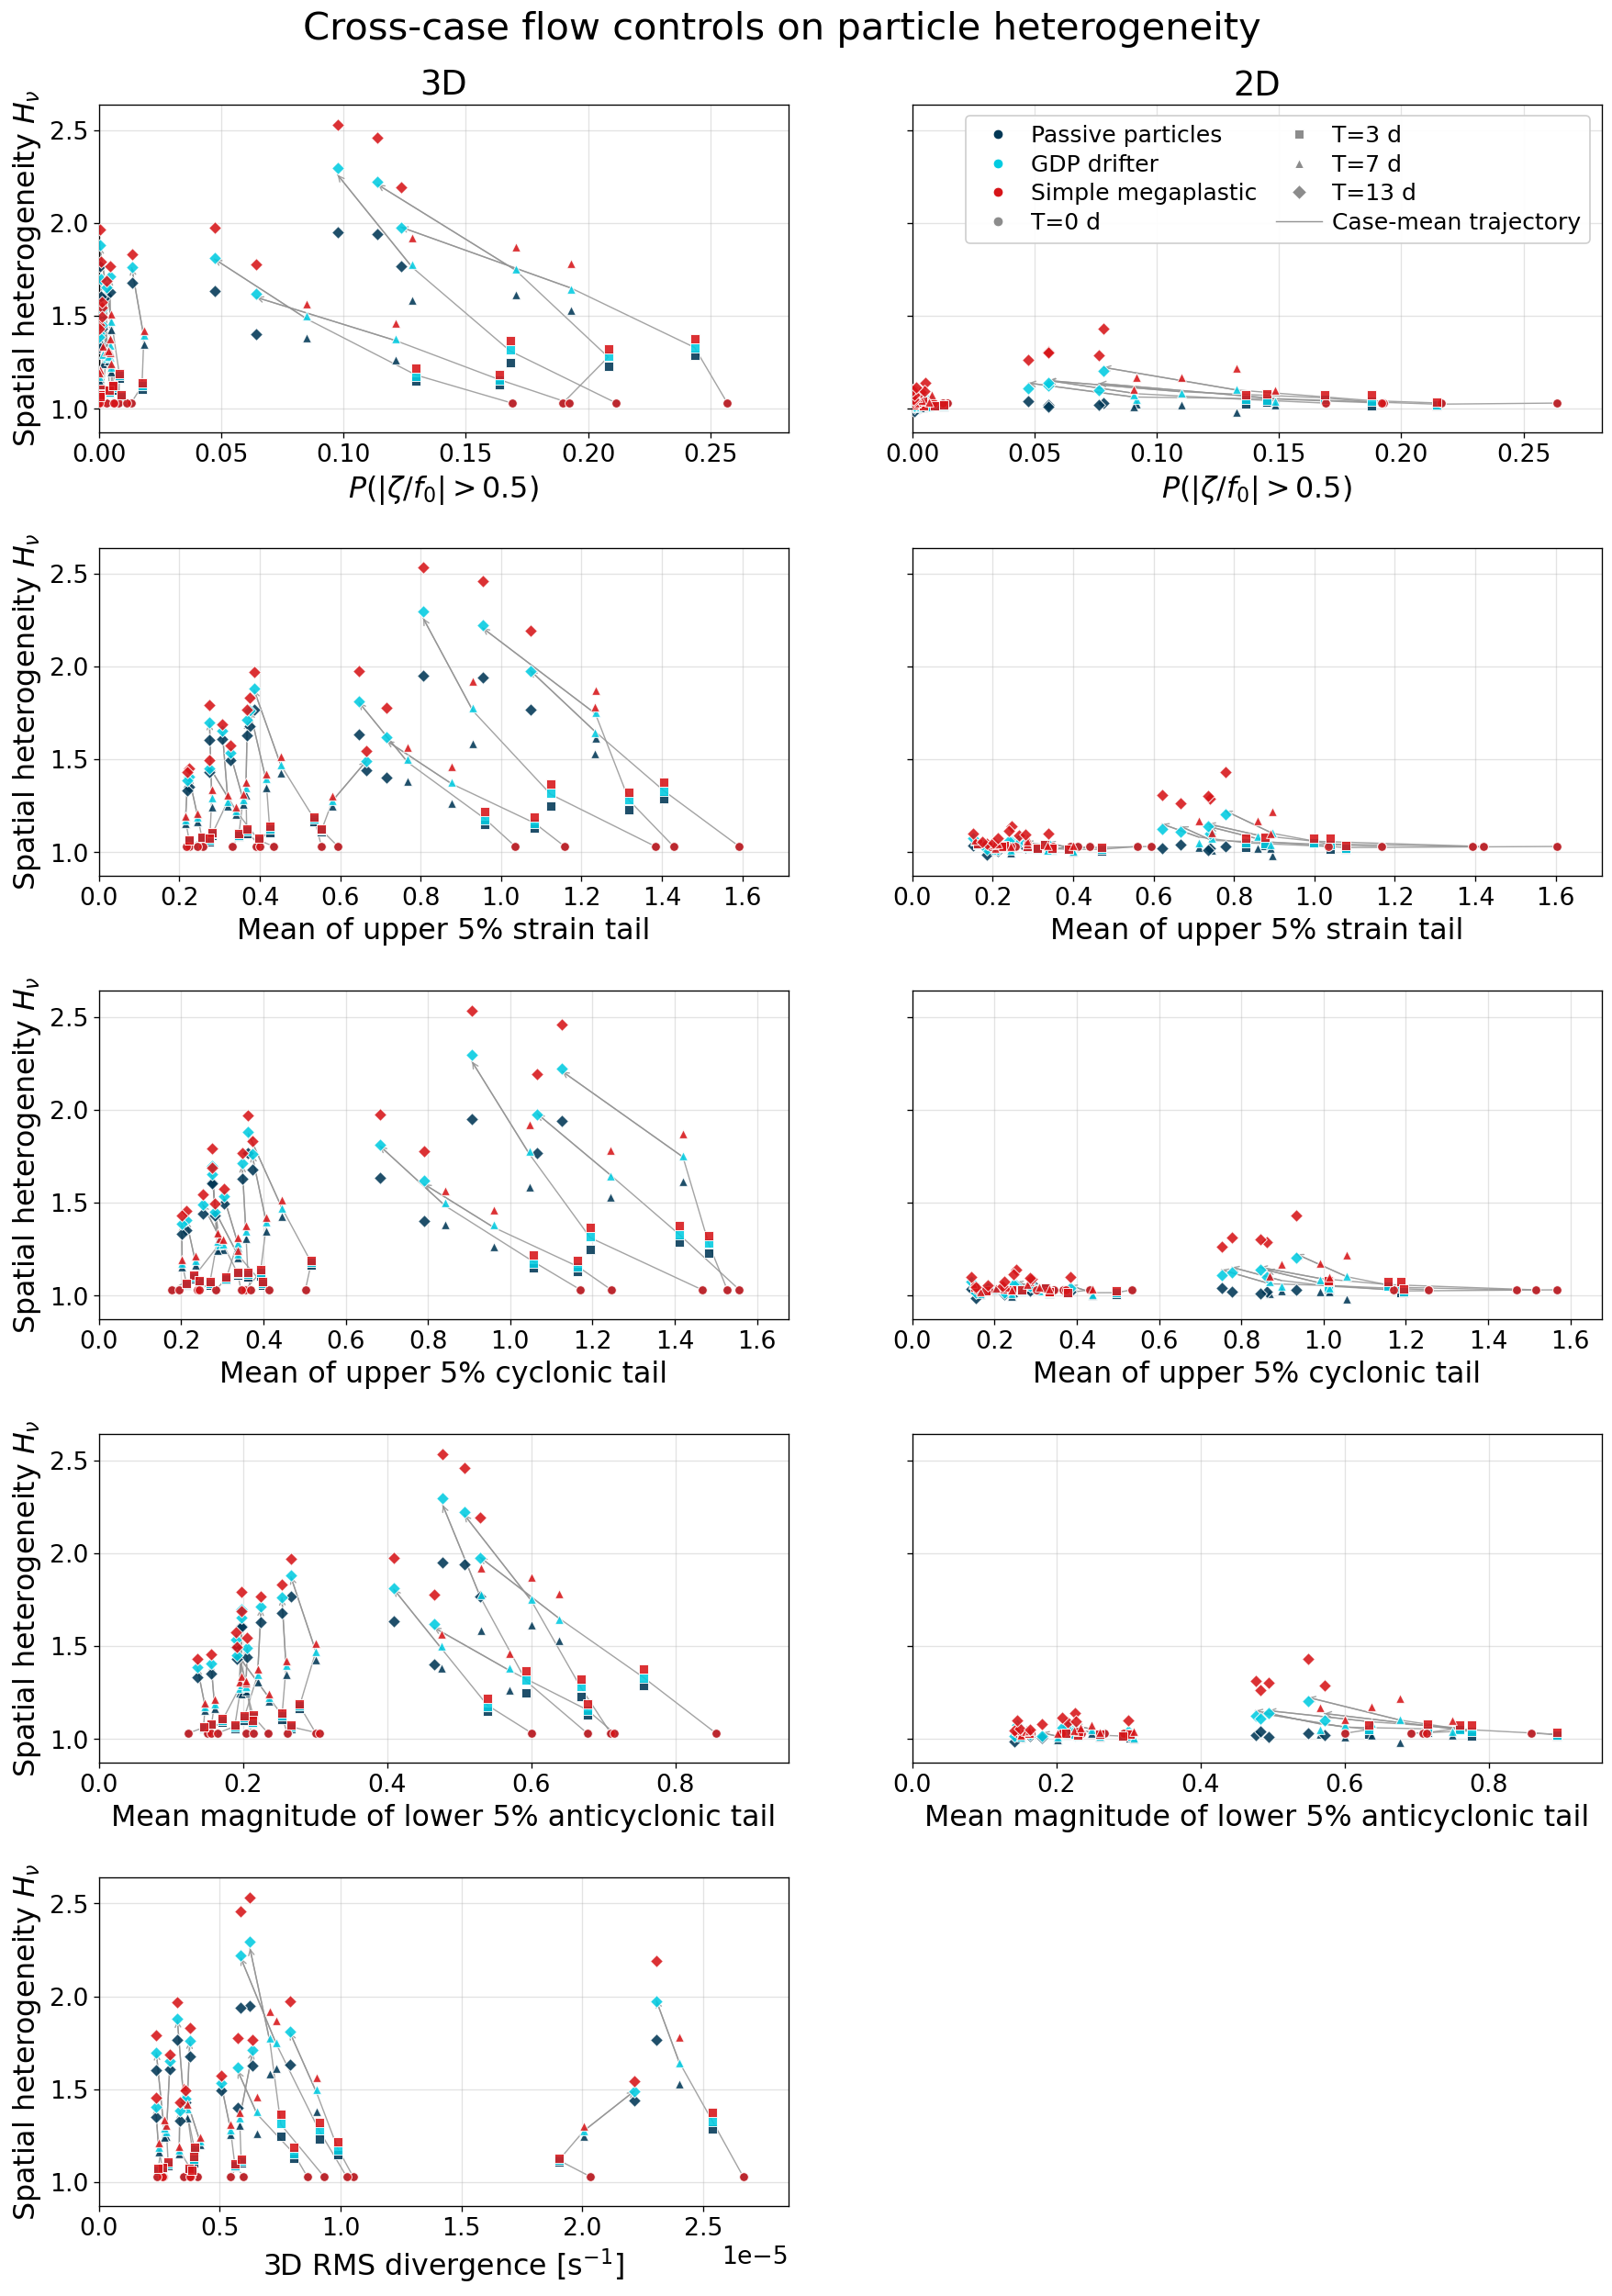

In [38]:
# ============================================================
# 8. CASE TRAJECTORIES IN ABSOLUTE FLOW-HETEROGENEITY SPACE
# ============================================================

apply_cross_case_style()
data = plot_df.copy()

# Check the underlying values before plotting. This distinguishes a
# plotting/autoscaling problem from a genuine cached-data problem.
divergence_diagnostic = print_divergence_diagnostic(data)
display(divergence_diagnostic)

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15.5, 21.2),
    sharey=True,
    facecolor="white",
    constrained_layout=False,
)

y_limits = padded_limits(
    np.r_[
        data["heterogeneity_3d"].to_numpy(dtype=float),
        data["heterogeneity_2d"].to_numpy(dtype=float),
    ]
)

axes[0, 0].set_title("3D")
axes[0, 1].set_title("2D")

for row_index, spec in enumerate(FLOW_CONTROL_ROWS):
    key_3d = spec["key_3d"]
    key_2d = spec["key_2d"]

    ax_3d = axes[row_index, 0]
    plot_panel_with_case_trajectories(
        ax_3d,
        data,
        x_key=key_3d,
        y_key="heterogeneity_3d",
    )
    format_panel(
        ax_3d,
        xlabel=spec["label"],
        ylabel=r"Spatial heterogeneity $H_\nu$",
    )
    if y_limits is not None:
        ax_3d.set_ylim(*y_limits)

    if key_2d is None:
        # This branch is the 3D-only RMS-divergence panel.
        # Previously it continued before setting x limits, allowing
        # FancyArrowPatch to distort Matplotlib's autoscaling.
        ax_3d.set_xlim(
            *nonnegative_limits(
                data[key_3d].to_numpy(dtype=float)
            )
        )
        axes[row_index, 1].axis("off")
        continue

    ax_2d = axes[row_index, 1]
    plot_panel_with_case_trajectories(
        ax_2d,
        data,
        x_key=key_2d,
        y_key="heterogeneity_2d",
    )
    format_panel(ax_2d, xlabel=spec["label"])
    if y_limits is not None:
        ax_2d.set_ylim(*y_limits)

    # Shared limits for direct 3D-versus-2D comparison.
    row_limits = nonnegative_limits(
        np.r_[
            data[key_3d].to_numpy(dtype=float),
            data[key_2d].to_numpy(dtype=float),
        ]
    )
    ax_3d.set_xlim(*row_limits)
    ax_2d.set_xlim(*row_limits)

axes[4, 0].ticklabel_format(
    axis="x",
    style="sci",
    scilimits=(0, 0),
)

# One combined legend inside the first 2D panel.
add_inside_legend(axes[0, 1])

fig.suptitle(
    "Cross-case flow controls on particle heterogeneity",
    y=0.995,
)
fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.055,
    top=0.955,
    hspace=0.35,
    wspace=0.18,
)

save_figure(
    fig,
    "particle_heterogeneity_flow_controls_tail_means_case_trajectories_all_classes",
)
plt.show()

In [39]:
# ============================================================
# 9. CASE-MEAN TRAJECTORY TABLE (CHECK)
# ============================================================

trajectory_summary = (
    plot_df[
        [
            "case_3d",
            "time_days",
            "heterogeneity_3d",
            "heterogeneity_2d",
        ]
    ]
    .groupby(["case_3d", "time_days"], as_index=False)
    .mean()
    .rename(
        columns={
            "heterogeneity_3d": "mean_heterogeneity_3d",
            "heterogeneity_2d": "mean_heterogeneity_2d",
        }
    )
    .sort_values(["case_3d", "time_days"])
)

display(trajectory_summary)

,case_3d,time_days,mean_heterogeneity_3d,mean_heterogeneity_2d
0,run_aug1_f1,0.0,1.031283,1.031229
1,run_aug1_f1,3.0,1.123897,1.018626
2,run_aug1_f1,7.0,1.387398,1.053345
3,run_aug1_f1,13.0,1.758415,1.072966
4,run_aug1_f2,0.0,1.031350,1.031325
5,run_aug1_f2,3.0,1.178460,1.016310
6,run_aug1_f2,7.0,1.471075,1.015782
7,run_aug1_f2,13.0,1.872134,1.054174
8,run_aug2,0.0,1.031334,1.031434
9,run_aug2,3.0,1.100485,1.025536


In [40]:
# ============================================================
# 10. OUTPUT CHECK
# ============================================================

print(f"Combined table  : {SUMMARY_CSV_PATH}")
print(f"Figure directory: {OUTPUT_DIR}")

generated = sorted(OUTPUT_DIR.glob("*"))
for path in generated:
    print(path.name)

if skipped_heterogeneity:
    print("\nSkipped heterogeneity cases:")
    for message in skipped_heterogeneity:
        print(f"  - {message}")

if skipped_flow:
    print("\nSkipped flow cases:")
    for message in skipped_flow:
        print(f"  - {message}")

Combined table  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_tail_means\particle_heterogeneity_flow_controls_tail_means.csv
Figure directory: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_flow_controls_tail_means
particle_heterogeneity_flow_controls_tail_means.csv
particle_heterogeneity_flow_controls_tail_means_case_trajectories_all_classes.pdf
particle_heterogeneity_flow_controls_tail_means_case_trajectories_all_classes.png

Skipped flow cases:
  - run_aug1: FileNotFoundError: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1_2D.nc
